# NjengaData — Visual Dashboard
### Notebook 03 | Visualization Specialist: Stacey Koigu

This notebook reads the processed data from the Analysis team
and produces the four charts that tell the NjengaData story.

**Input:** Four CSV files from `data/processed/`
**Output:** Four charts saved to `data/processed/charts/`

| Chart | File | Story |
|---|---|---|
| Stacked Bar | q1_nairobi_2br_breakdown.csv | Where the money goes in Nairobi |
| County Comparison | q2_county_comparison.csv | Which county builds cheapest |
| Material Trends | q3_material_trends.csv | Five years of inflation |
| Affordability Gap | q4_affordability_gap.csv | Years of income to build |

> *"Numbers tell. Charts show. Stories move."*

---
## Section 1: Imports and Configuration

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Working directory fix ─────────────────────────────────────────
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# ── Paths ─────────────────────────────────────────────────────────
PROCESSED_PATH = "data/processed"
CHARTS_PATH    = "data/processed/charts"

os.makedirs(CHARTS_PATH, exist_ok=True)

# ── Global style ──────────────────────────────────────────────────
# One style call affects all charts consistently
sns.set_theme(style="whitegrid", font="DejaVu Sans")

# ── Colour palette ────────────────────────────────────────────────
# Five colours — one per cost category — used consistently across all charts
CATEGORY_COLOURS = {
    "Land"       : "#1F4E79",
    "Materials"  : "#2E75B6",
    "Labour"     : "#70AD47",
    "Compliance" : "#ED7D31",
    "Overheads"  : "#A5A5A5",
}

COUNTY_COLOURS = {
    "Nairobi" : "#1F4E79",
    "Kiambu"  : "#2E75B6",
    "Mombasa" : "#ED7D31",
    "Nakuru"  : "#70AD47",
}

print("Libraries loaded.")
print(f"Charts will be saved to: {CHARTS_PATH}")

Libraries loaded.
Charts will be saved to: data/processed/charts


---
## Section 2: Load Processed Data

We load all four CSVs produced by Mohamed's analysis notebook.
We never touch the database — Stacey reads only from processed files.

In [10]:
# Load all four processed datasets
df_q1 = pd.read_csv(os.path.join(PROCESSED_PATH, "q1_nairobi_2br_breakdown.csv"))
df_q2 = pd.read_csv(os.path.join(PROCESSED_PATH, "q2_county_comparison.csv"))
df_q3 = pd.read_csv(os.path.join(PROCESSED_PATH, "q3_material_trends.csv"))
df_q4 = pd.read_csv(os.path.join(PROCESSED_PATH, "q4_affordability_gap.csv"))

print("Datasets loaded:")
print(f"  Q1 — Nairobi 2BR breakdown : {df_q1.shape}")
print(f"  Q2 — County comparison     : {df_q2.shape}")
print(f"  Q3 — Material trends       : {df_q3.shape}")
print(f"  Q4 — Affordability gap     : {df_q4.shape}")

Datasets loaded:
  Q1 — Nairobi 2BR breakdown : (5, 3)
  Q2 — County comparison     : (20, 4)
  Q3 — Material trends       : (18, 3)
  Q4 — Affordability gap     : (4, 6)


---
## Section 3: Chart 1 — Nairobi 2BR Cost Breakdown
**Story:** Where does the money go when building a 2-bedroom house in Nairobi?

A stacked horizontal bar chart. One bar. Five segments.
Land consumes 25.8% before a single brick is laid.
Compliance takes 12.7% — pure regulatory cost.

*Source: CAHF Kenya Housing Development Cost Benchmark Report 2022*

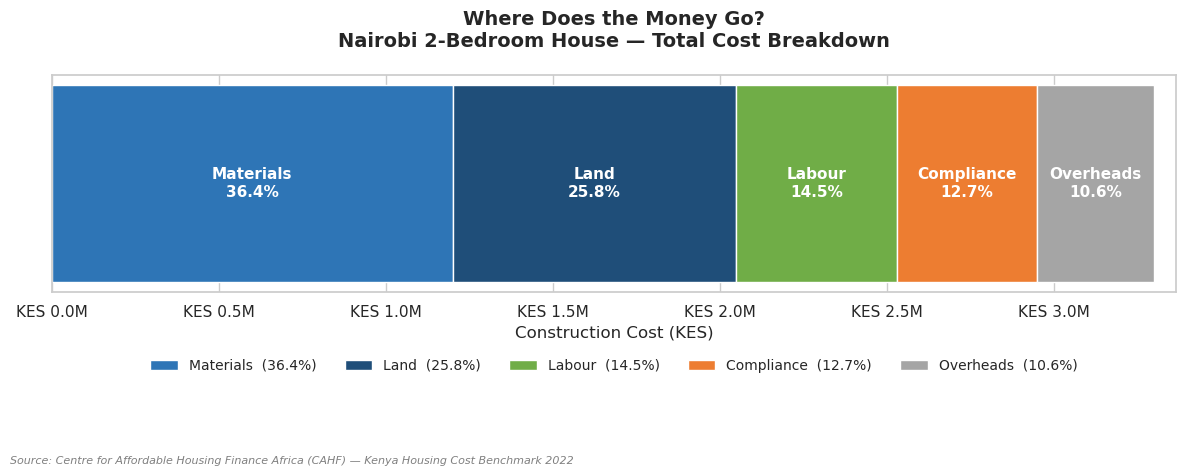

Chart 1 saved: data/processed/charts/chart1_nairobi_breakdown.png


In [11]:
# ── Prepare data ──────────────────────────────────────────────────
# Sort by amount so largest segment sits at the bottom of the stack
q1_sorted = df_q1.sort_values('total_kes', ascending=False)

categories = q1_sorted['cost_category'].tolist()
values     = q1_sorted['total_kes'].tolist()
percentages= q1_sorted['percentage'].tolist()
colours    = [CATEGORY_COLOURS[cat] for cat in categories]

# ── Build chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

# Build the stacked bar segment by segment
left = 0
bars = []
for i, (cat, val, pct, col) in enumerate(zip(categories, values, percentages, colours)):
    bar = ax.barh(
        y      = 0,
        width  = val,
        left   = left,
        color  = col,
        height = 0.5,
        label  = f"{cat}  ({pct}%)"
    )
    bars.append(bar)

    # Label each segment — only if wide enough to fit text
    if pct >= 10:
        ax.text(
            left + val / 2, 0,
            f"{cat}\n{pct}%",
            ha='center', va='center',
            color='white', fontsize=11, fontweight='bold'
        )
    left += val

# ── Formatting ────────────────────────────────────────────────────
ax.set_xlim(0, sum(values) * 1.02)
ax.set_yticks([])
ax.set_xlabel("Construction Cost (KES)", fontsize=12)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"KES {x/1e6:.1f}M")
)

ax.set_title(
    "Where Does the Money Go?\nNairobi 2-Bedroom House — Total Cost Breakdown",
    fontsize=14, fontweight='bold', pad=20
)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=5,
    fontsize=10,
    frameon=False
)

# Source citation — every chart must have one
fig.text(
    0.01, -0.18,
    "Source: Centre for Affordable Housing Finance Africa (CAHF) — Kenya Housing Cost Benchmark 2022",
    fontsize=8, color='grey', style='italic'
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.25)

# ── Save and show ─────────────────────────────────────────────────
chart1_path = os.path.join(CHARTS_PATH, "chart1_nairobi_breakdown.png")
plt.savefig(chart1_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 1 saved: {chart1_path}")

---
## Section 4: Chart 2 — County Cost Comparison
**Story:** How does the cost of building a 2BR house differ across counties?

Nakuru is KES 1,167,000 cheaper than Nairobi for the exact same house.
The gap is not just price — it is where the cost pressure sits in each market.

*Source: CAHF Kenya Housing Development Cost Benchmark Report 2022*

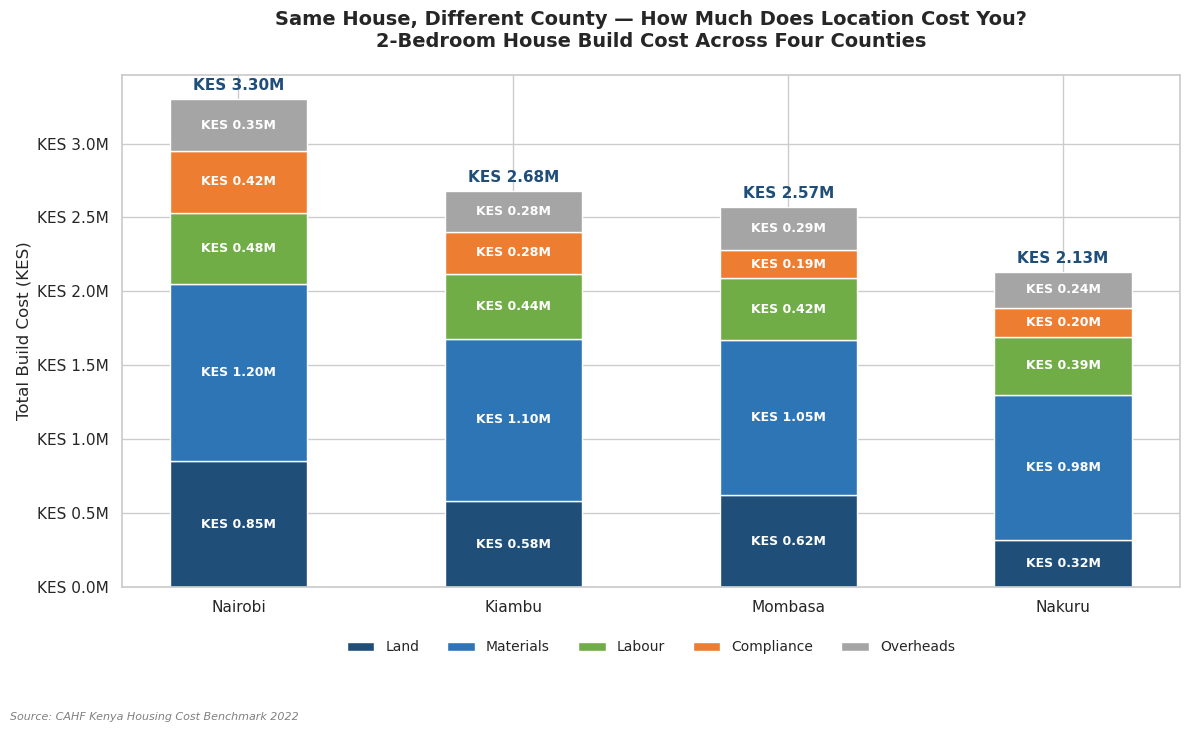

Chart 2 saved: data/processed/charts/chart2_county_comparison.png


In [12]:
# ── Prepare data ──────────────────────────────────────────────────
# Pivot — counties as columns, categories as rows
q2_pivot = df_q2.pivot_table(
    index   = 'cost_category',
    columns = 'county',
    values  = 'total_kes',
    aggfunc = 'sum'
).reindex(['Land', 'Materials', 'Labour', 'Compliance', 'Overheads'])

# County order — most expensive to cheapest left to right
county_order  = df_q2.groupby('county')['total_kes'].sum()\
                      .sort_values(ascending=False).index.tolist()
q2_pivot      = q2_pivot[county_order]

# ── Build chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Build stacked bars county by county
bottom = pd.Series([0.0] * len(county_order), index=county_order)

for category in ['Land', 'Materials', 'Labour', 'Compliance', 'Overheads']:
    values = q2_pivot.loc[category]
    ax.bar(
        x      = county_order,
        height = values,
        bottom = bottom,
        color  = CATEGORY_COLOURS[category],
        label  = category,
        width  = 0.5
    )
    # Label each segment if tall enough
    for i, county in enumerate(county_order):
        segment_height = values[county]
        if segment_height > 80000:
            ax.text(
                i, bottom[county] + segment_height / 2,
                f"KES {segment_height/1e6:.2f}M",
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold'
            )
    bottom += values

# Total cost label above each bar
totals = df_q2.groupby('county')['total_kes'].sum()
for i, county in enumerate(county_order):
    ax.text(
        i, totals[county] + 40000,
        f"KES {totals[county]/1e6:.2f}M",
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#1F4E79'
    )

# ── Formatting ────────────────────────────────────────────────────
ax.set_ylabel("Total Build Cost (KES)", fontsize=12)
ax.set_xlabel("")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"KES {x/1e6:.1f}M")
)
ax.set_title(
    "Same House, Different County — How Much Does Location Cost You?\n2-Bedroom House Build Cost Across Four Counties",
    fontsize=14, fontweight='bold', pad=20
)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=5,
    fontsize=10,
    frameon=False
)
fig.text(
    0.01, -0.04,
    "Source: CAHF Kenya Housing Cost Benchmark 2022",
    fontsize=8, color='grey', style='italic'
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)

# ── Save and show ─────────────────────────────────────────────────
chart2_path = os.path.join(CHARTS_PATH, "chart2_county_comparison.png")
plt.savefig(chart2_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 2 saved: {chart2_path}")

---
## Section 5: Chart 3 — Material Price Trends (2019–2024)
**Story:** How have cement, steel and timber prices moved over five years?

Cement has risen 23% — steadily, with no relief.
Steel spiked sharply in 2021-2022 then softened.
Contractors cannot stockpile cement — every pour costs more than the last.

*Source: KNBS Construction Input Price Index 2019–2024*

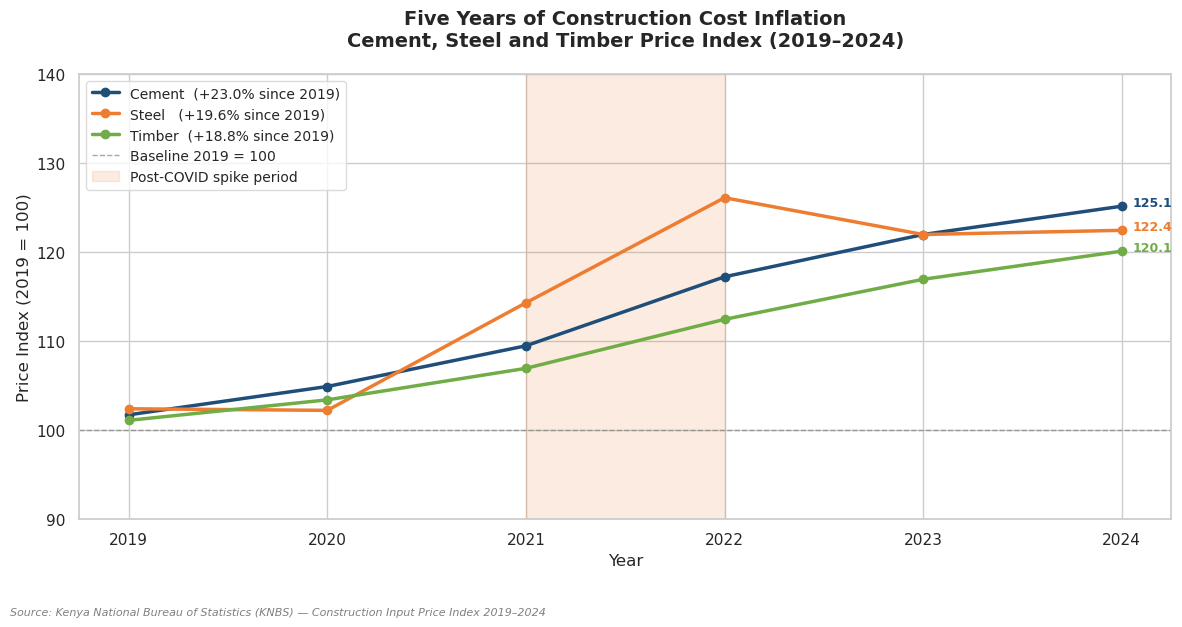

Chart 3 saved: data/processed/charts/chart3_material_trends.png


In [13]:
# ── Prepare data ──────────────────────────────────────────────────
# Pivot — years as index, materials as columns
q3_pivot = df_q3.pivot_table(
    index   = 'year',
    columns = 'material',
    values  = 'avg_annual_index'
)

MATERIAL_COLOURS = {
    'cement' : '#1F4E79',
    'steel'  : '#ED7D31',
    'timber' : '#70AD47',
}
MATERIAL_LABELS = {
    'cement' : f'Cement  (+23.0% since 2019)',
    'steel'  : f'Steel   (+19.6% since 2019)',
    'timber' : f'Timber  (+18.8% since 2019)',
}

# ── Build chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for material in ['cement', 'steel', 'timber']:
    ax.plot(
        q3_pivot.index,
        q3_pivot[material],
        color     = MATERIAL_COLOURS[material],
        linewidth = 2.5,
        marker    = 'o',
        markersize= 6,
        label     = MATERIAL_LABELS[material]
    )
    # Annotate the 2024 endpoint with the final index value
    final_val = q3_pivot.loc[2024, material]
    ax.annotate(
        f"{final_val:.1f}",
        xy         = (2024, final_val),
        xytext     = (8, 0),
        textcoords = 'offset points',
        fontsize   = 9,
        color      = MATERIAL_COLOURS[material],
        fontweight = 'bold'
    )

# Reference line at 100 — the 2019 baseline
ax.axhline(
    y         = 100,
    color     = 'grey',
    linewidth = 1,
    linestyle = '--',
    alpha     = 0.7,
    label     = 'Baseline 2019 = 100'
)

# Shade the post-COVID spike period
ax.axvspan(2021, 2022, alpha=0.15, color='#ED7D31', label='Post-COVID spike period')

# ── Formatting ────────────────────────────────────────────────────
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Price Index (2019 = 100)", fontsize=12)
ax.set_xticks(q3_pivot.index)
ax.set_ylim(90, 140)
ax.set_title(
    "Five Years of Construction Cost Inflation\nCement, Steel and Timber Price Index (2019–2024)",
    fontsize=14, fontweight='bold', pad=20
)
ax.legend(
    loc       = 'upper left',
    fontsize  = 10,
    frameon   = True,
    edgecolor = 'lightgrey'
)
fig.text(
    0.01, -0.04,
    "Source: Kenya National Bureau of Statistics (KNBS) — Construction Input Price Index 2019–2024",
    fontsize=8, color='grey', style='italic'
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.12)

# ── Save and show ─────────────────────────────────────────────────
chart3_path = os.path.join(CHARTS_PATH, "chart3_material_trends.png")
plt.savefig(chart3_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 3 saved: {chart3_path}")

---
## Section 6: Chart 4 — Affordability Gap
**Story:** Can a median household in each county afford to build a 2BR house?

Mombasa is the real affordability trap — not Nairobi.
Lower absolute cost, but significantly lower income means
a Mombasa household needs 5.4 years of full income to build.
Nairobi households need 4.6 years.

No county comes close to affordable. That is the point.

*Source: CAHF 2022 / World Bank Kenya Household Income Data*

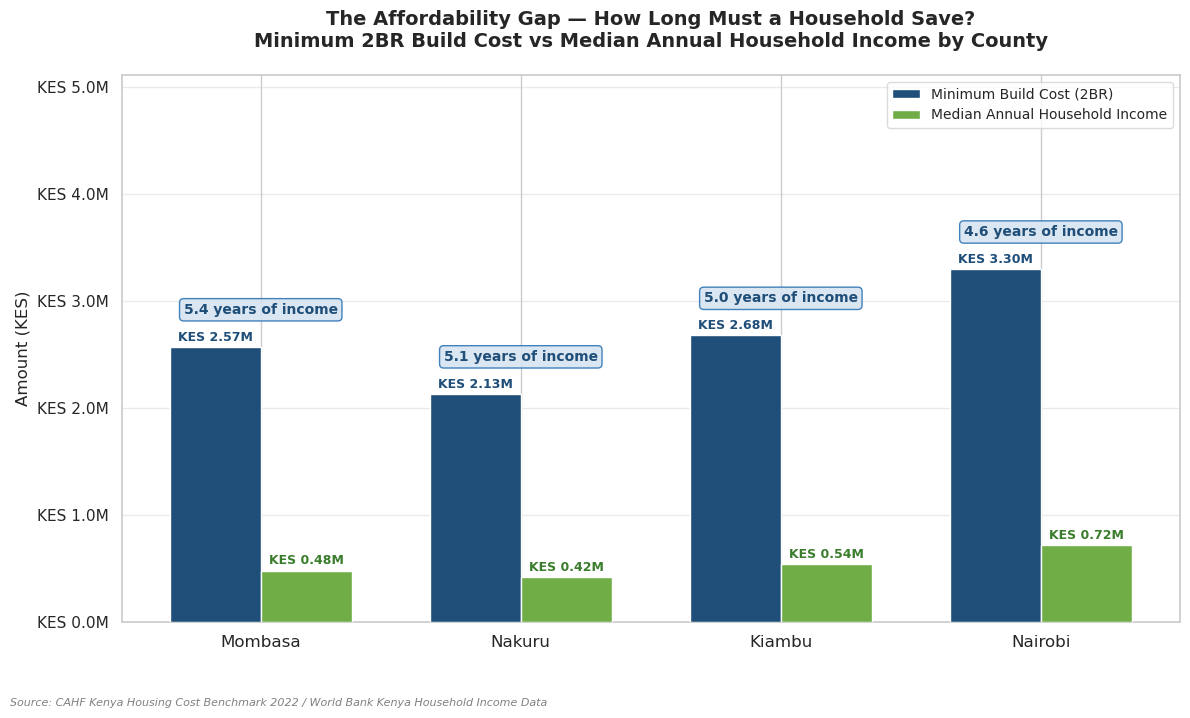

Chart 4 saved: data/processed/charts/chart4_affordability_gap.png


In [14]:
# ── Prepare data ──────────────────────────────────────────────────
# Sort by years of income — most unaffordable first
q4_sorted = df_q4.sort_values('years_of_income', ascending=False)

counties        = q4_sorted['county'].tolist()
build_costs     = q4_sorted['min_build_cost_kes'].tolist()
annual_incomes  = q4_sorted['median_annual_income_kes'].tolist()
years_needed    = q4_sorted['years_of_income'].tolist()

x      = range(len(counties))
width  = 0.35

# ── Build chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(
    [i - width/2 for i in x],
    build_costs,
    width = width,
    color = '#1F4E79',
    label = 'Minimum Build Cost (2BR)',
    zorder= 3
)
bars2 = ax.bar(
    [i + width/2 for i in x],
    annual_incomes,
    width = width,
    color = '#70AD47',
    label = 'Median Annual Household Income',
    zorder= 3
)

# Label build cost bars
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30000,
        f"KES {bar.get_height()/1e6:.2f}M",
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#1F4E79'
    )

# Label income bars
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30000,
        f"KES {bar.get_height()/1e6:.2f}M",
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#3A7D2C'
    )

# Annotate years of income above each county pair
for i, (county, years) in enumerate(zip(counties, years_needed)):
    ax.text(
        i, max(build_costs[i], annual_incomes[i]) + 280000,
        f"{years} years of income",
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#1F4E79',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#D6E4F0', edgecolor='#2E75B6', alpha=0.9)
    )

# ── Formatting ────────────────────────────────────────────────────
ax.set_xticks(list(x))
ax.set_xticklabels(counties, fontsize=12)
ax.set_ylabel("Amount (KES)", fontsize=12)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"KES {x/1e6:.1f}M")
)
ax.set_title(
    "The Affordability Gap — How Long Must a Household Save?\n"
    "Minimum 2BR Build Cost vs Median Annual Household Income by County",
    fontsize=14, fontweight='bold', pad=20
)
ax.legend(
    loc            = 'upper right',
    fontsize       = 10,
    frameon        = True,
    edgecolor      = 'lightgrey'
)
ax.set_ylim(0, max(build_costs) * 1.55)
ax.grid(axis='y', alpha=0.4, zorder=0)

fig.text(
    0.01, -0.02,
    "Source: CAHF Kenya Housing Cost Benchmark 2022 / World Bank Kenya Household Income Data",
    fontsize=8, color='grey', style='italic'
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.10)

# ── Save and show ─────────────────────────────────────────────────
chart4_path = os.path.join(CHARTS_PATH, "chart4_affordability_gap.png")
plt.savefig(chart4_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 4 saved: {chart4_path}")

---
## Section 7: Dashboard Complete

All four charts have been generated and saved to `data/processed/charts/`.

| Chart | File | Key Finding |
|---|---|---|
| 1 — Nairobi Breakdown | chart1_nairobi_breakdown.png | Land eats 25.8% before construction begins |
| 2 — County Comparison | chart2_county_comparison.png | Nakuru is KES 1.17M cheaper than Nairobi |
| 3 — Material Trends | chart3_material_trends.png | Cement up 23% — no correction in sight |
| 4 — Affordability Gap | chart4_affordability_gap.png | Mombasa is the real affordability trap |

**Presentation note for Stacey:**
Each chart has two sentences. Lead with the finding, not the description.
- Not: *"This chart shows the cost breakdown of a 2BR house in Nairobi."*
- Yes: *"Before a single brick is laid, Land and Compliance have already consumed 38% of the budget."*

In [15]:
# Final confirmation — verify all four charts exist and are non-empty
print("Chart files verification:")
print("-" * 55)

chart_files = [
    "chart1_nairobi_breakdown.png",
    "chart2_county_comparison.png",
    "chart3_material_trends.png",
    "chart4_affordability_gap.png",
]

all_good = True
for filename in chart_files:
    filepath = os.path.join(CHARTS_PATH, filename)
    exists   = os.path.exists(filepath)
    size     = os.path.getsize(filepath) if exists else 0
    status   = "OK" if exists and size > 0 else "MISSING"
    if status == "MISSING":
        all_good = False
    print(f"  [{status}]  {filename:<45} {size:>8,} bytes")

print("-" * 55)
print(f"\nAll charts present: {all_good}")
print("\nNjengaData dashboard is complete.")

Chart files verification:
-------------------------------------------------------
  [OK]  chart1_nairobi_breakdown.png                    88,797 bytes
  [OK]  chart2_county_comparison.png                   139,790 bytes
  [OK]  chart3_material_trends.png                     141,804 bytes
  [OK]  chart4_affordability_gap.png                   131,205 bytes
-------------------------------------------------------

All charts present: True

NjengaData dashboard is complete.
